# Part - 1 Beginning the Tutorial

You can access the signature + docstring via **?** command and to print the complete class definition can use the **??** operator

In [41]:
from sionna.phy.mapping import Mapper
import sionna

sionna.phy.mapping.Mapper?

sionna.phy.mapping.Mapper??

Init signature:
sionna.phy.mapping.Mapper(
    constellation_type: Optional[str] = None,
    num_bits_per_symbol: Optional[int] = None,
    constellation: Optional[sionna.phy.mapping.Constellation] = None,
    return_indices: bool = False,
    precision: Optional[Literal['single', 'double']] = None,
    device: Optional[str] = None,
    **kwargs: Any,
) -> None
Source:        
class Mapper(Block):
    r"""
    Maps binary tensors to points of a constellation.

    This class defines a block that maps a tensor of binary values
    to a tensor of points from a provided constellation.

    :param constellation_type: Type of constellation. One of "qam", "pam", or "custom".
        For "custom", an instance of :class:`~sionna.phy.mapping.Constellation`
        must be provided.
    :param num_bits_per_symbol: The number of bits per constellation symbol,
        e.g., 4 for QAM16. Only required for ``constellation_type`` in ["qam", "pam"].
    :param constellation: If no constellation is pro

*Can run bash commands with $!$*

In [42]:
!nvidia-smi

Tue Jul 21 14:55:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.04              Driver Version: 596.21         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P8              1W /  175W |     242MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Sionna instantiates RNGs for Python, NumPy, PyTorch which can be optionally set to a seed.

In [43]:
import torch

# Without this line the randint will give the same answer ever again.
sionna.phy.config.seed = 30

# Python RNG 
# instead of 
# 
# import random
# random.randint(0, 10)
print(sionna.phy.config.py_rng.randint(0, 10))


# NumPy RNG
# instead of
# 
# import numpy as np
# np.random.randint(0, 10)
print(sionna.phy.config.np_rng.integers(0, 10))


# PyTorch RNG
# instead of
#
# import torch
# torch.randint(0, 10, (1, ))
torch_gen = sionna.phy.config.torch_rng()
device = sionna.phy.config.device
print(torch.randint(0, 10, (1,), device=device, generator=torch_gen).item())

8
1
7


## Transmitting QAM Symbols over an AWGN channel

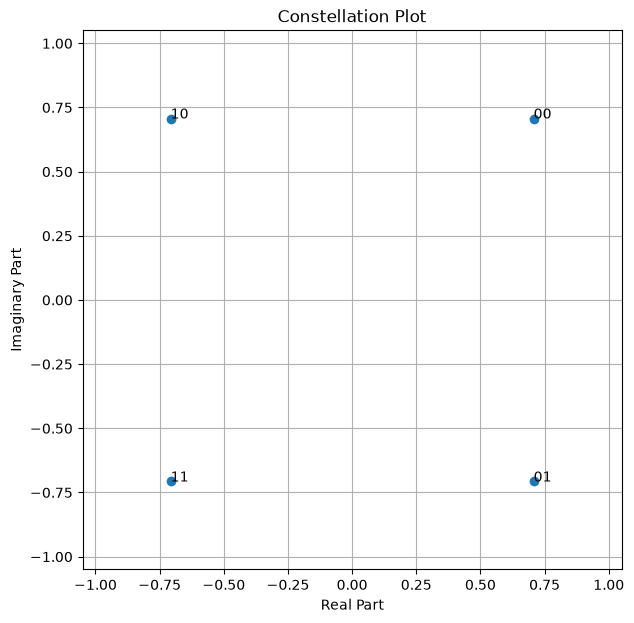

In [44]:
from sionna.phy.mapping import Mapper, Constellation, BinarySource, Demapper
from sionna.phy.channel import AWGN
from sionna.phy.utils import ebnodb2no

NUM_BITS_PER_SYMBOL = 2 # QPSK for 2
                        # 16-QAM for 4

constellation = Constellation("qam", NUM_BITS_PER_SYMBOL)

constellation.show();

In [45]:
mapper = Mapper(constellation=constellation)

demapper = Demapper("app", constellation=constellation)

source = BinarySource()

awgn = AWGN()

EBNO_DB = 10.0
CODE_RATE = 1.0

no = ebnodb2no( EBNO_DB, NUM_BITS_PER_SYMBOL, CODE_RATE )

With this setup, we have all components we need to transmit QAM symbols over an AWGN channel. Sionna natively supports multi-dimensional tensors.

In [46]:
BATCH_SIZE = 64
BLOCK_LENGTH = 1024

bits = source([ BATCH_SIZE, BLOCK_LENGTH ])

print("Shape of bits: ", bits.shape)

x = mapper(bits)

print("Shape of x: ", x.shape)

y = awgn(x, no)
print("Shape of y: ", y.shape)

llr = demapper(y, no)
print("Shape of llr: ", llr.shape)

Shape of bits:  torch.Size([64, 1024])
Shape of x:  torch.Size([64, 512])
Shape of y:  torch.Size([64, 512])
Shape of llr:  torch.Size([64, 1024])


In [48]:
import numpy as np
import matplotlib.pyplot as plt

num_samples = 8 # how many samples shall be printed
num_symbols = int(num_samples/NUM_BITS_PER_SYMBOL)

print(f"First {num_samples} transmitted bits: {bits[0,:num_samples]}")
print(f"First {num_symbols} transmitted symbols: {np.round(x.cpu()[0,:num_symbols], 2)}")
print(f"First {num_symbols} received symbols: {np.round(y.cpu()[0,:num_symbols], 2)}")
print(f"First {num_samples} demapped llrs: {np.round(llr.cpu()[0,:num_samples], 2)}")

First 8 transmitted bits: tensor([1., 1., 0., 1., 1., 0., 0., 1.], device='cuda:0')
First 4 transmitted symbols: tensor([-0.7100-0.7100j,  0.7100-0.7100j, -0.7100+0.7100j,  0.7100-0.7100j])
First 4 received symbols: tensor([-0.7500-0.7300j,  0.7200-0.7300j, -0.5900+0.6600j,  0.9700-0.7800j])
First 8 demapped llrs: tensor([ 42.2200,  41.5100, -40.5200,  41.4300,  33.5900, -37.3900, -54.8000,
         43.9700])


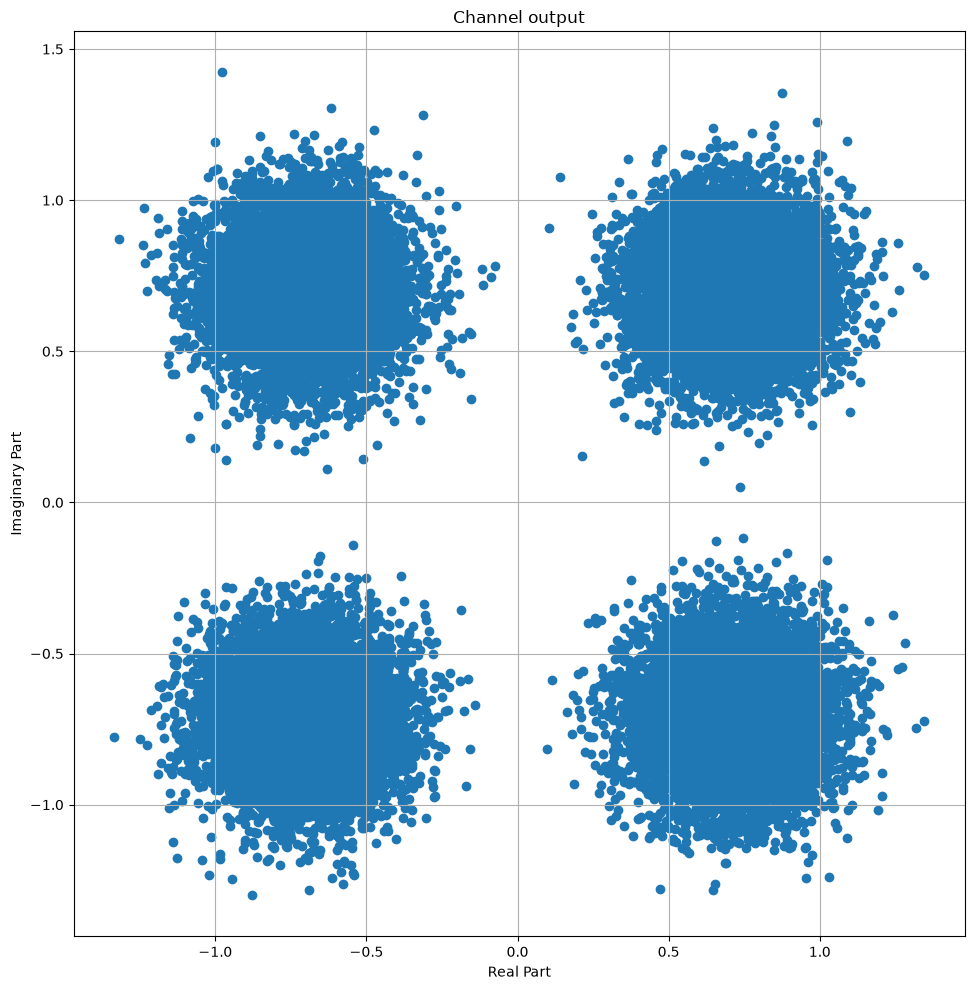

In [49]:
plt.figure(figsize=(10,10))
plt.axes().set_aspect(1)
plt.grid(True)
plt.title('Channel output')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.scatter(y.cpu().real.flatten().numpy(), y.cpu().imag.flatten().numpy())
plt.tight_layout()

## End to End Systems in Sionna

In [56]:
from sionna.phy import Block
from sionna.phy.mapping import Mapper, Demapper
from sionna.phy.mapping import Constellation, BinarySource
from sionna.phy.channel import AWGN
from sionna.phy.utils import ebnodb2no

class UncodedSystemAWGN(Block):

    def __init__(self, num_bits_per_symbol, block_length):


        super().__init__()


        self.num_bits_per_symbol = num_bits_per_symbol
        self.block_length = block_length

        self.constellation = Constellation("qam", self.num_bits_per_symbol)
        
        self.mapper = Mapper(constellation=self.constellation)
        self.demapper = Demapper("app", constellation=self.constellation)
        
        self.binary_source = BinarySource()

        self.awgn_channel = AWGN()


    def call(self, batch_size, ebno_db):

        no = ebnodb2no( ebno_db, num_bits_per_symbol=self.num_bits_per_symbol, coderate=1.0)

        bits = self.binary_source( [batch_size, self.block_length] )

        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y, no)

        return bits, llr

Now that we have wrapped the whole process into one class, we can use it.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -3.0 | 1.5819e-01 | 1.0000e+00 |      323977 |     2048000 |         2000 |        2000 |         0.1 |reached target block errors
   -2.579 | 1.4692e-01 | 1.0000e+00 |      300886 |     2048000 |         2000 |        2000 |         0.0 |reached target block errors
   -2.158 | 1.3485e-01 | 1.0000e+00 |      276164 |     2048000 |         2000 |        2000 |         0.0 |reached target block errors
   -1.737 | 1.2358e-01 | 1.0000e+00 |      253099 |     2048000 |         2000 |        2000 |         0.0 |reached target block errors
   -1.316 | 1.1233e-01 | 1.0000e+00 |      230052 |     2048000 |         2000 |        2000 |         0.0 |reached target block errors
   -0.895 | 1.0107e-01 | 1.0000e+00 |      206982 |     2048000 |

(tensor([0.1582, 0.1469, 0.1348, 0.1236, 0.1123, 0.1011, 0.0904, 0.0798, 0.0698,
         0.0609, 0.0522, 0.0441, 0.0368, 0.0301, 0.0244, 0.0191, 0.0149, 0.0112,
         0.0083, 0.0058], device='cuda:0'),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 0.9985], device='cuda:0'))

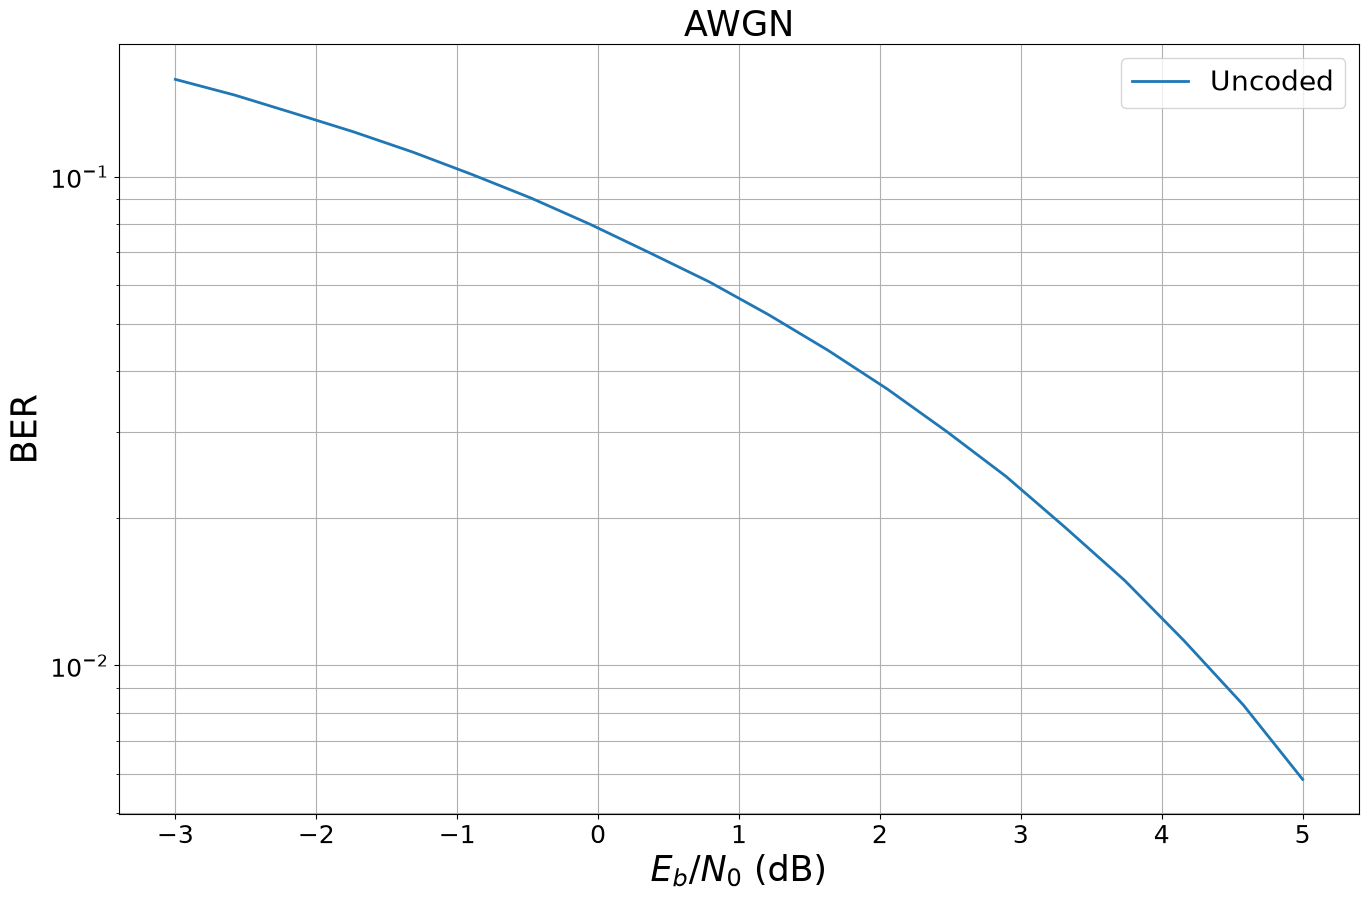

In [58]:
model_uncoded_awgn = UncodedSystemAWGN(

    num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
    block_length=1024

)

from sionna.phy.utils import PlotBER

ber_plots = PlotBER("AWGN")

# print(model_uncoded_awgn.dtype)

EBN0_DB_MIN = -3.0
EBN0_DB_MAX = 5.0
BATCH_SIZE = 2000

ber_plots.simulate(

    model_uncoded_awgn,
    ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
    batch_size=BATCH_SIZE,
    num_target_block_errors=100,
    legend="Uncoded",
    soft_estimates=True,
    max_mc_iter=100,
    show_fig=True

)